# SUPPORT2 Dataset: Exploratory Data Analysis
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Exploratory Data Analysis** phase of the project pipeline:

1. Detect Outliers
1. Univariate Analysis
1. Bivariate Analsysis
1. Demographic Analsysis
1. Disease Group Analysis
1. DNR Status Analysis

# 

---
# Learnings from the 1990s study
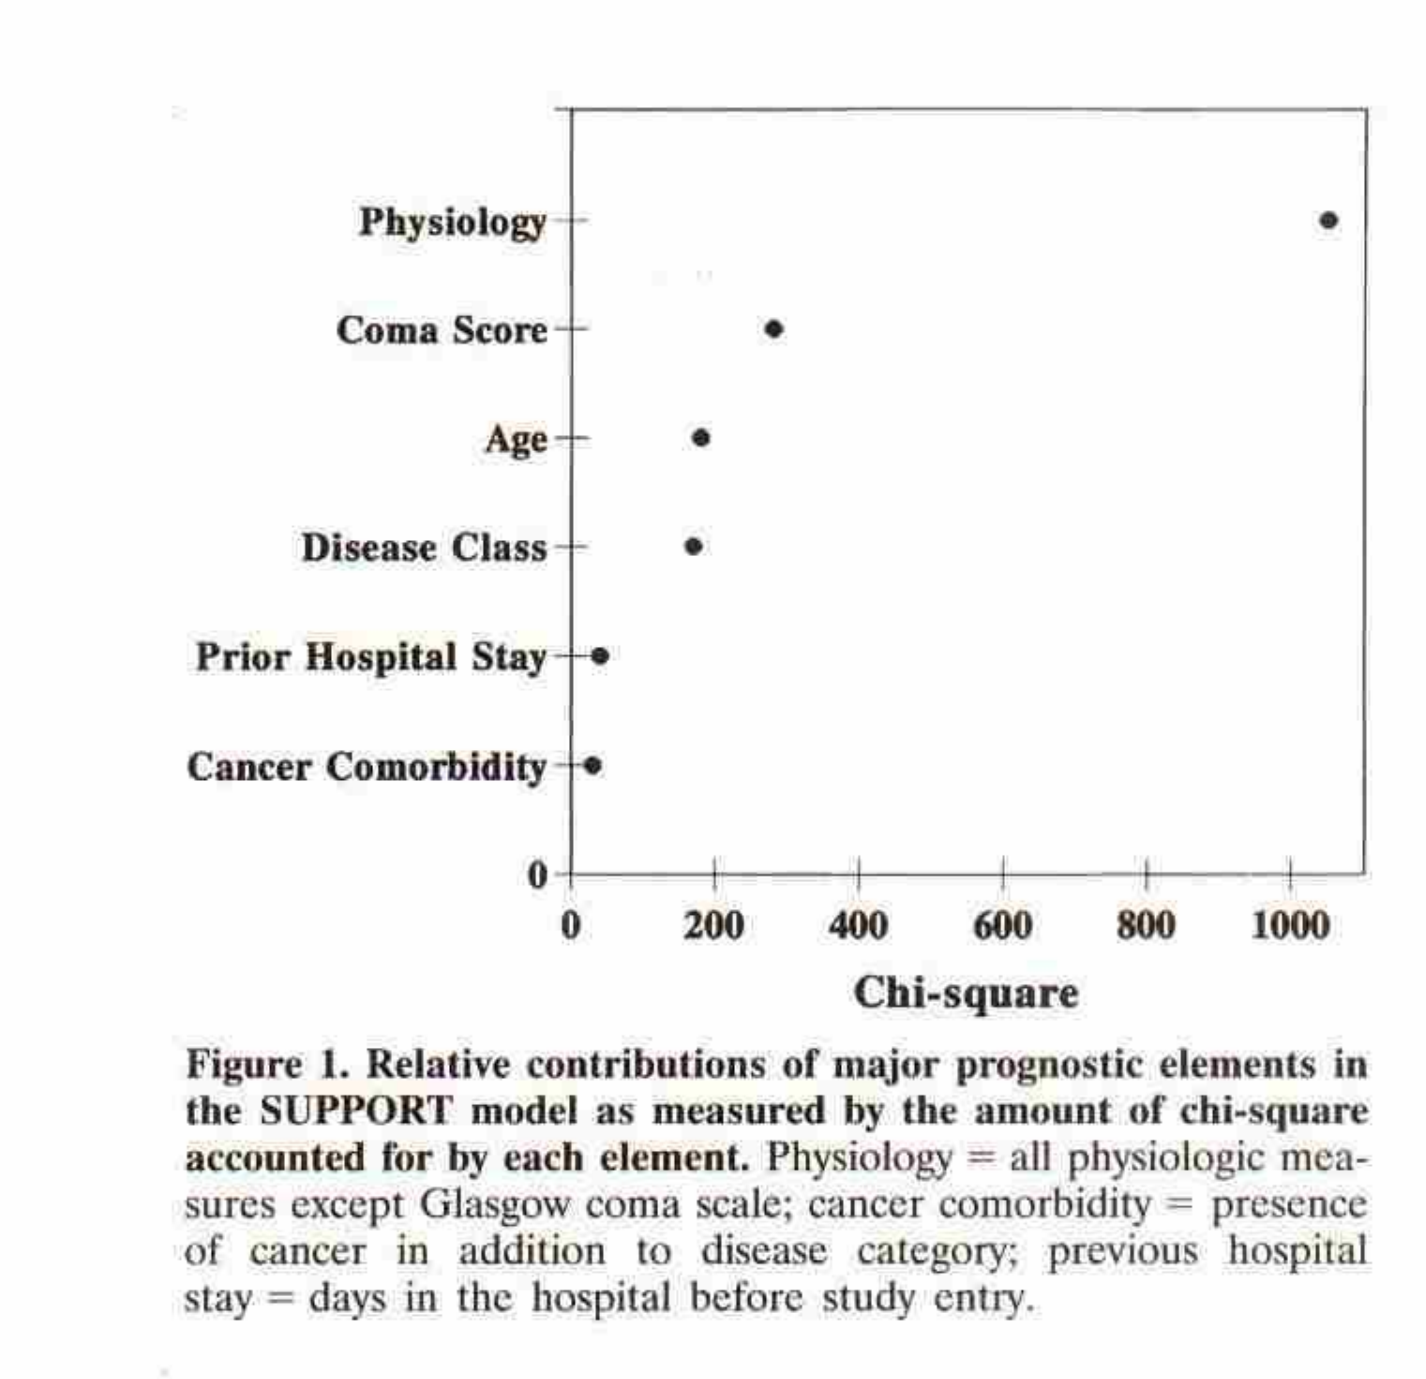
To inform our work, we review Knaus et al's (1995) paper.
According to Knaus et al these features were most weighted in their model:
- Physiology Score (calculated from wbc, albumin, etc). Some salient ones are Blood Pressure and Oxygenation levels
- Neurological Function (Glasgow coma scale)
- Patient age (but only when coupled with certain diseases like COPD)
- Apache III score
- Disease-Specific Interactions: The mathematical weight of certain features was explicitly programmed to vary based on the patient's primary disease:Albumin x Disease: A low albumin level strongly predicted death in cancer, COPD, and congestive heart failure, but was relatively unimportant in coma or MOSF.  WBC x Disease: A low WBC count was specifically associated with a greater risk of death in acute respiratory failure and MOSF.  Age x Disease: Advancing age heavily impacted short-term survival in COPD but had almost no incremental effect on patients with severe acute complications like MOSF or malignancy.  

---
## Section 0: Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402

warnings.filterwarnings("ignore")

---
## Section 1: Load Cleaned Data

In [2]:
df = load_csv("support2_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

OUTCOME_COLS = ["death", "hospdead", "d_time", "slos"]
ID_COLS = ["id"]
TARGET_COL = "death_180d"
BENCHMARK_COLS = ["surv2m", "surv6m", "aps", "sps", "prg2m", "prg6m", "dnr"]
LAB_COLS = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
]
FEATURE_COLS = [
    c
    for c in df.columns
    if c not in OUTCOME_COLS + ID_COLS + [TARGET_COL] + BENCHMARK_COLS
]

survivors = df[df[TARGET_COL] == 0]
died = df[df[TARGET_COL] == 1]
overall_rate = df[TARGET_COL].mean()
print(f"Survived 180d   : {len(survivors):,}  ({1 - overall_rate:.1%})")
print(f"Died within 180d: {len(died):,}  ({overall_rate:.1%})")

Shape: 9,105 rows  x  46 columns
Survived 180d   : 4,840  (53.2%)
Died within 180d: 4,265  (46.8%)


---
## Section 2: Physiology Outlier Detection (IQR Method)

```
IQR = Q3 - Q1
Lo whisker = Q1 - 1.5IQR
Hi whisker = Q3 + 1.5IQR
```

- Urine boxplot median is pushed all the way right because of imputation with Norm-Fill. 
- Glucose boxplot collapses due to high number of imputed NAs.
- **Probably better to run outliers before imputation**

In [3]:
def compute_iqr_outliers(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = int(((df[col] < lo) | (df[col] > hi)).sum())
        rows.append(
            {
                "Column": col,
                "Q1": round(float(Q1), 3),
                "Q3": round(float(Q3), 3),
                "IQR": round(float(IQR), 3),
                "Lo Whisker": round(float(lo), 3),
                "Hi Whisker": round(float(hi), 3),
                "Outliers": outliers,
                "Outlier %": round(outliers / len(df) * 100, 1),
            }
        )
    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)


outlier_df = compute_iqr_outliers(df, LAB_COLS)
print(
    outlier_df[
        ["Column", "Lo Whisker", "Hi Whisker", "Outliers", "Outlier %"]
    ].to_string(index=False)
)

 Column  Lo Whisker  Hi Whisker  Outliers  Outlier %
glucose     128.500     140.500      4323       47.5
  urine    1434.500    3142.500      2361       25.9
   bili      -0.450       2.350      1397       15.3
     ph       7.325       7.524      1107       12.2
   crea      -0.600       3.400       987       10.8
    bun     -19.725      50.235       916       10.1
   wblc      -5.149      27.249       431        4.7
   resp       3.000      43.000       313        3.4
    sod     123.500     151.500       256        2.8
    alb       1.499       4.700       154        1.7
   pafi     -49.950     563.250        59        0.6
    hrt       0.000     192.000        40        0.4
   temp      33.195      41.195        14        0.2
 meanbp      -3.000     173.000         6        0.1


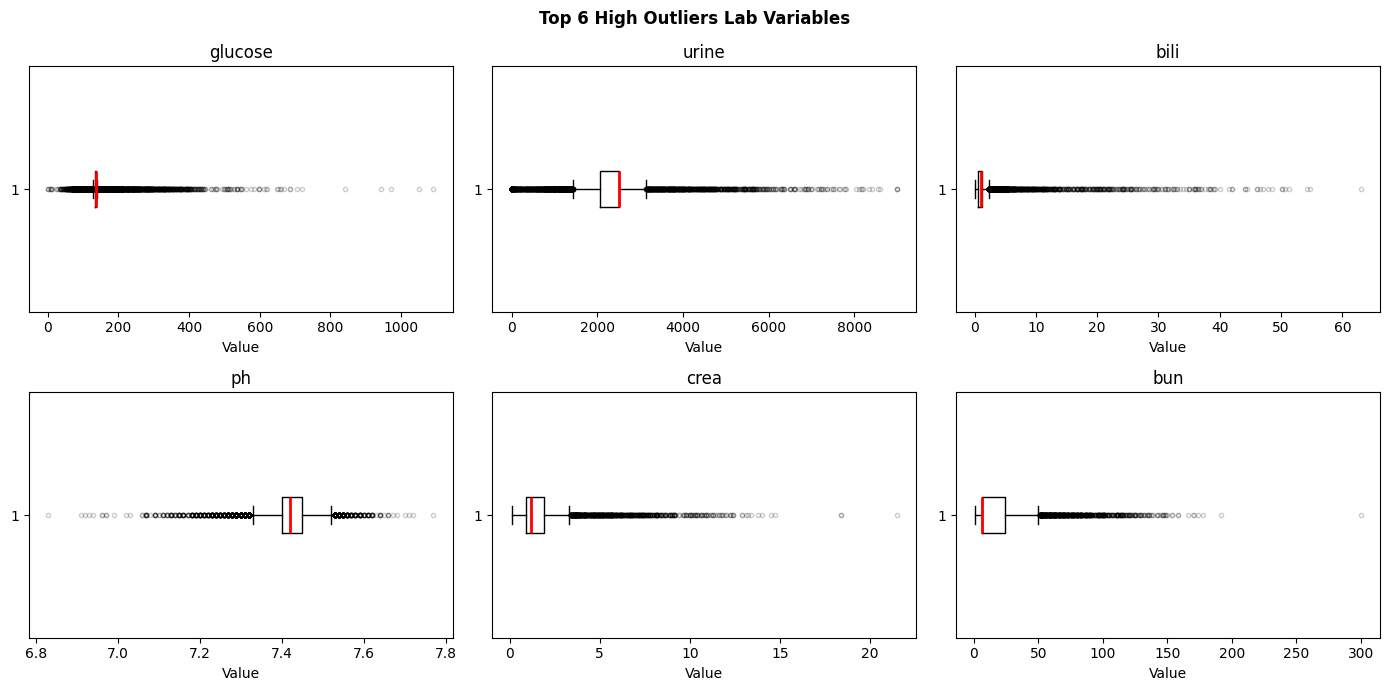

In [4]:
top6 = outlier_df.head(6)["Column"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(top6):
    axes.flat[i].boxplot(
        df[col],
        vert=False,
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", alpha=0.2, markersize=3, color="gray"),
    )
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
fig.suptitle("Top 6 High Outliers Lab Variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 3: Univariate Distributions

- Lab features are mainly right skewed
- Some imputations cause spikeness (glucose, pafi, bili)

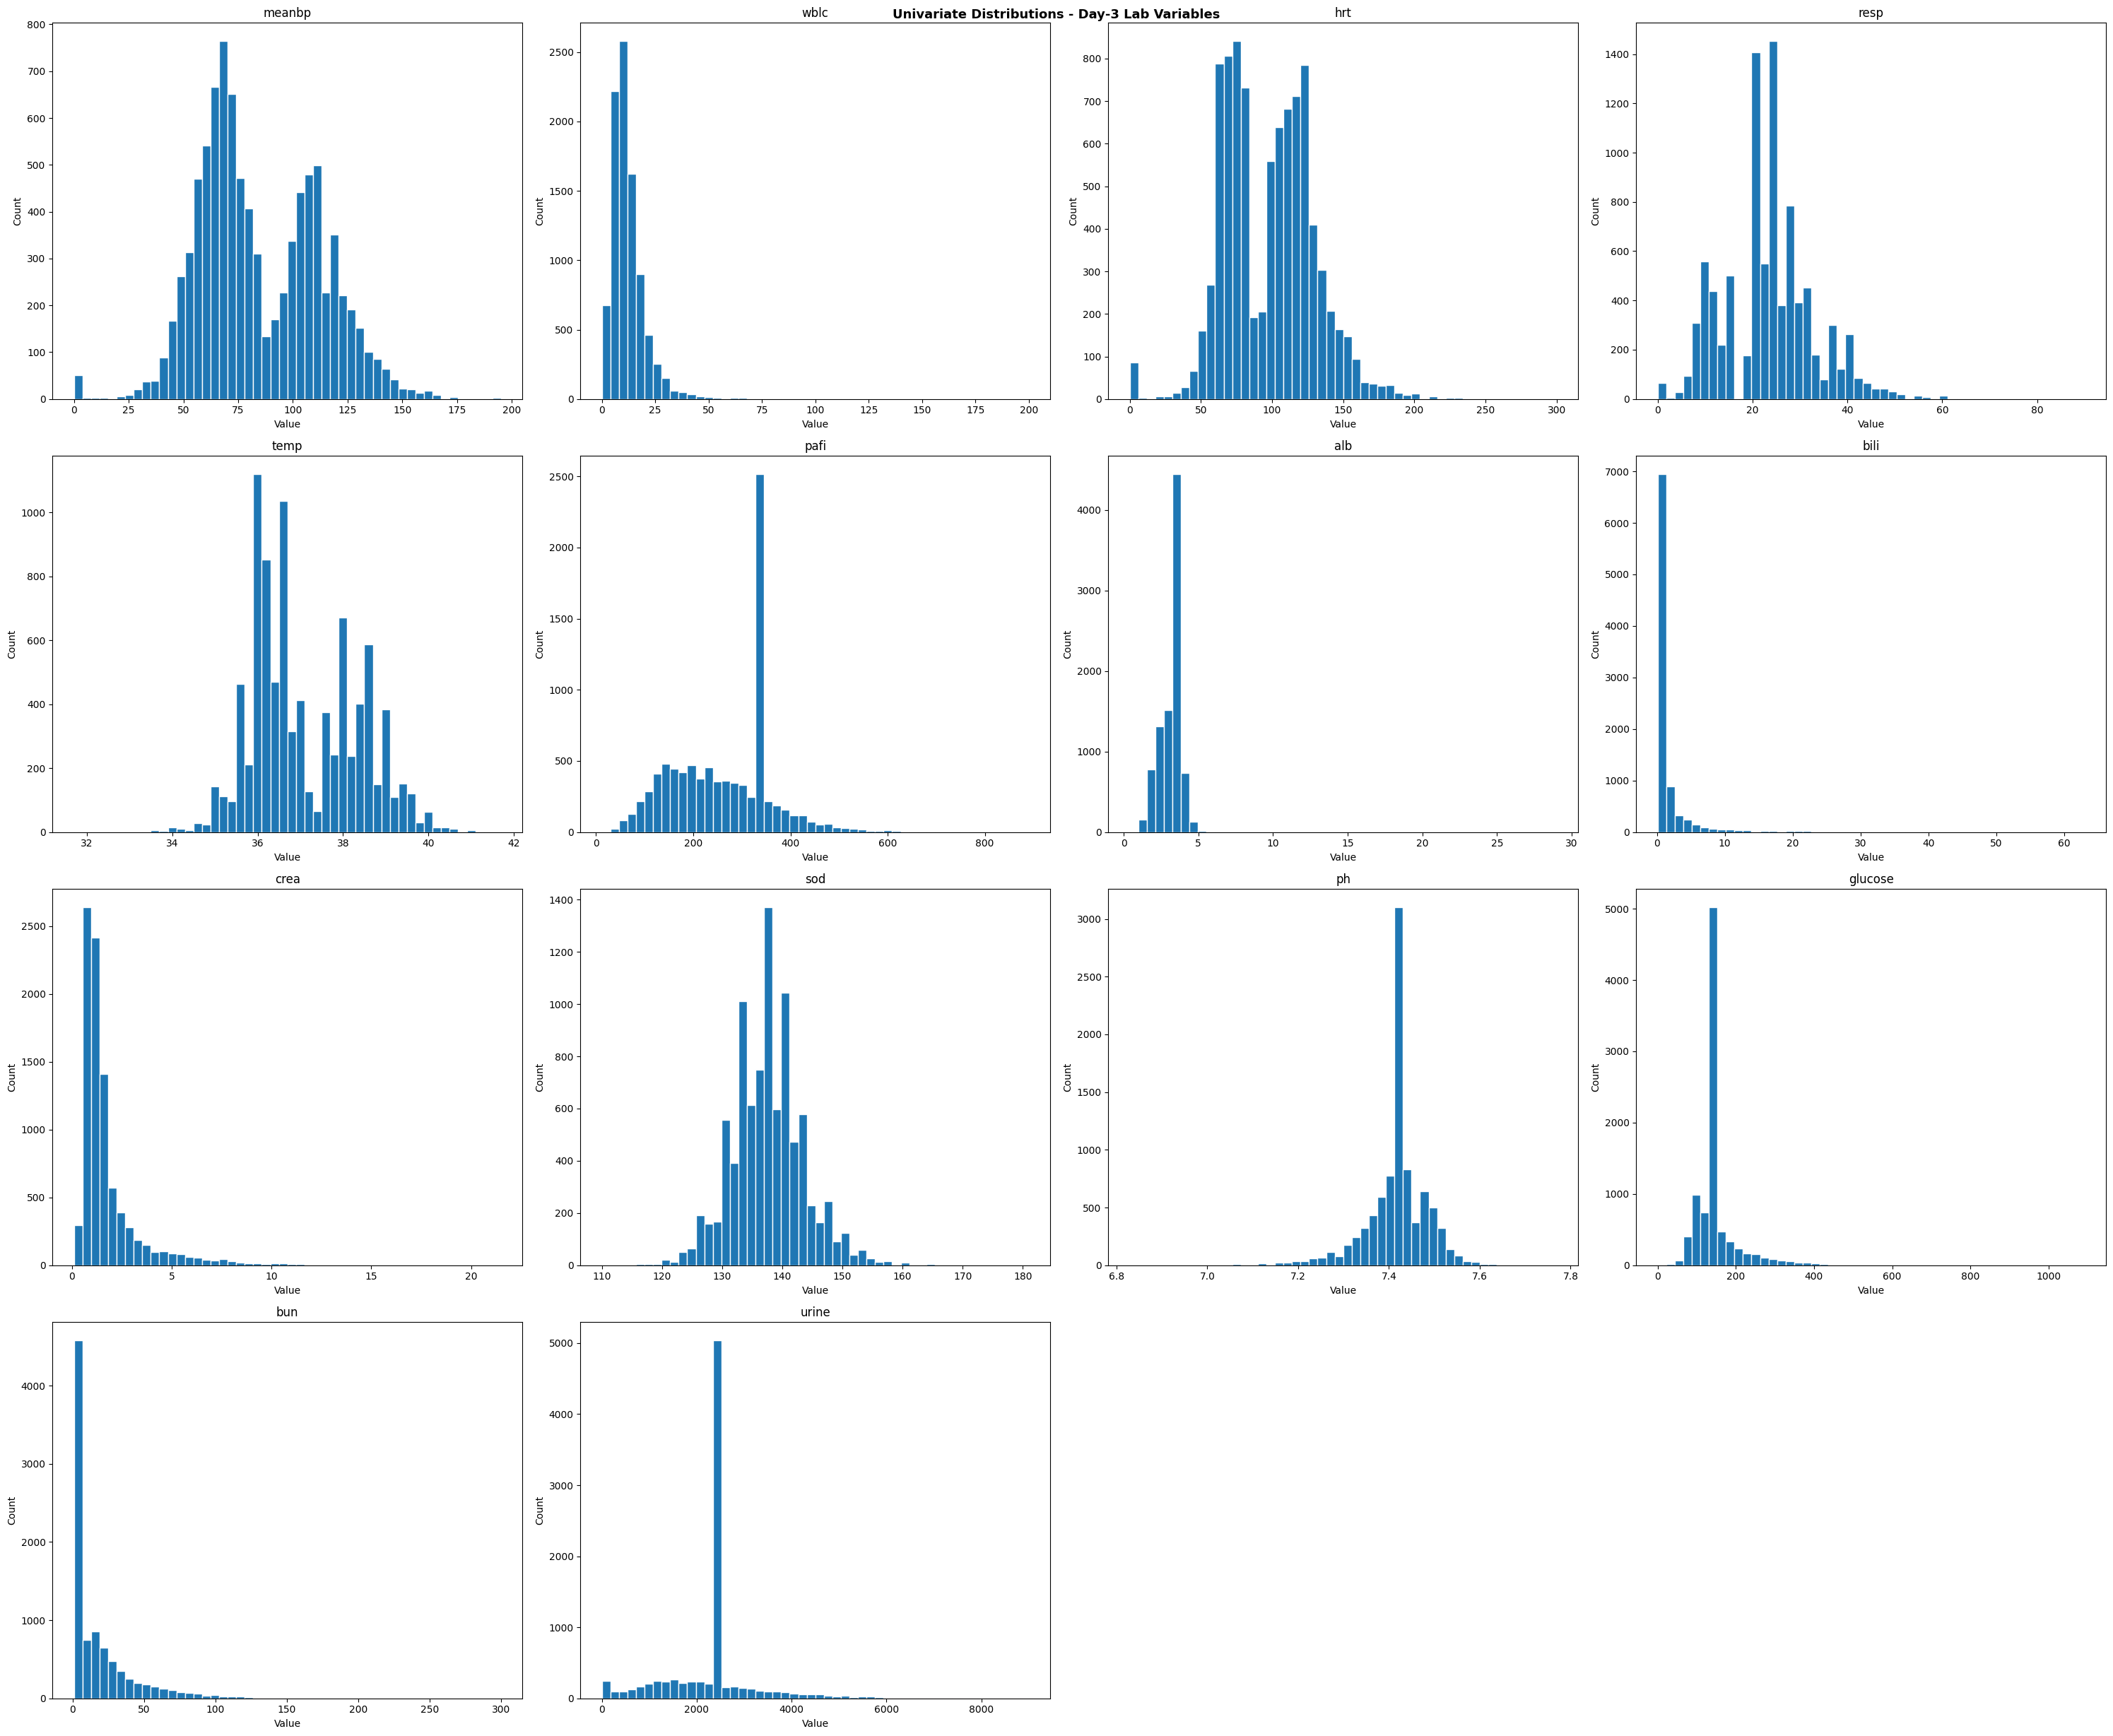

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(30, 25))
for i, col in enumerate(LAB_COLS):
    axes.flat[i].hist(df[col], bins=50, edgecolor="white")
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
    axes.flat[i].set_ylabel("Count")
for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)
fig.suptitle(
    "Univariate Distributions - Day-3 Lab Variables", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 3.1 Age follows normal distribution

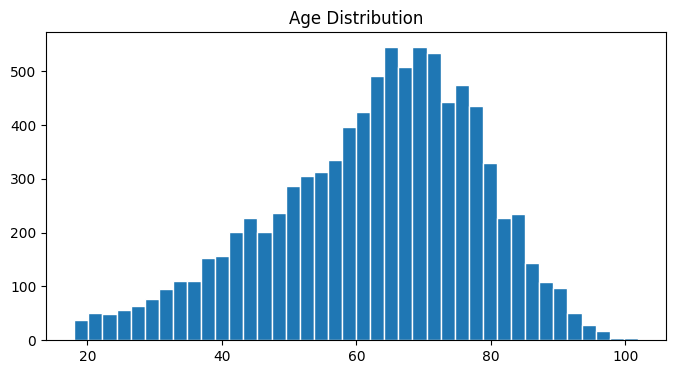

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["age"], bins=40, edgecolor="white")

ax.set_title("Age Distribution")
plt.show()

---
## Section 4: Bivariate Analysis - Lab Values by Survival Outcome

- Difficult to see any impact these lab values make with this analysis
- The paper did say this only becomes evident when combined with Disease group. For example, a high creatine with kidney failure gives high likelihood of mortality. 

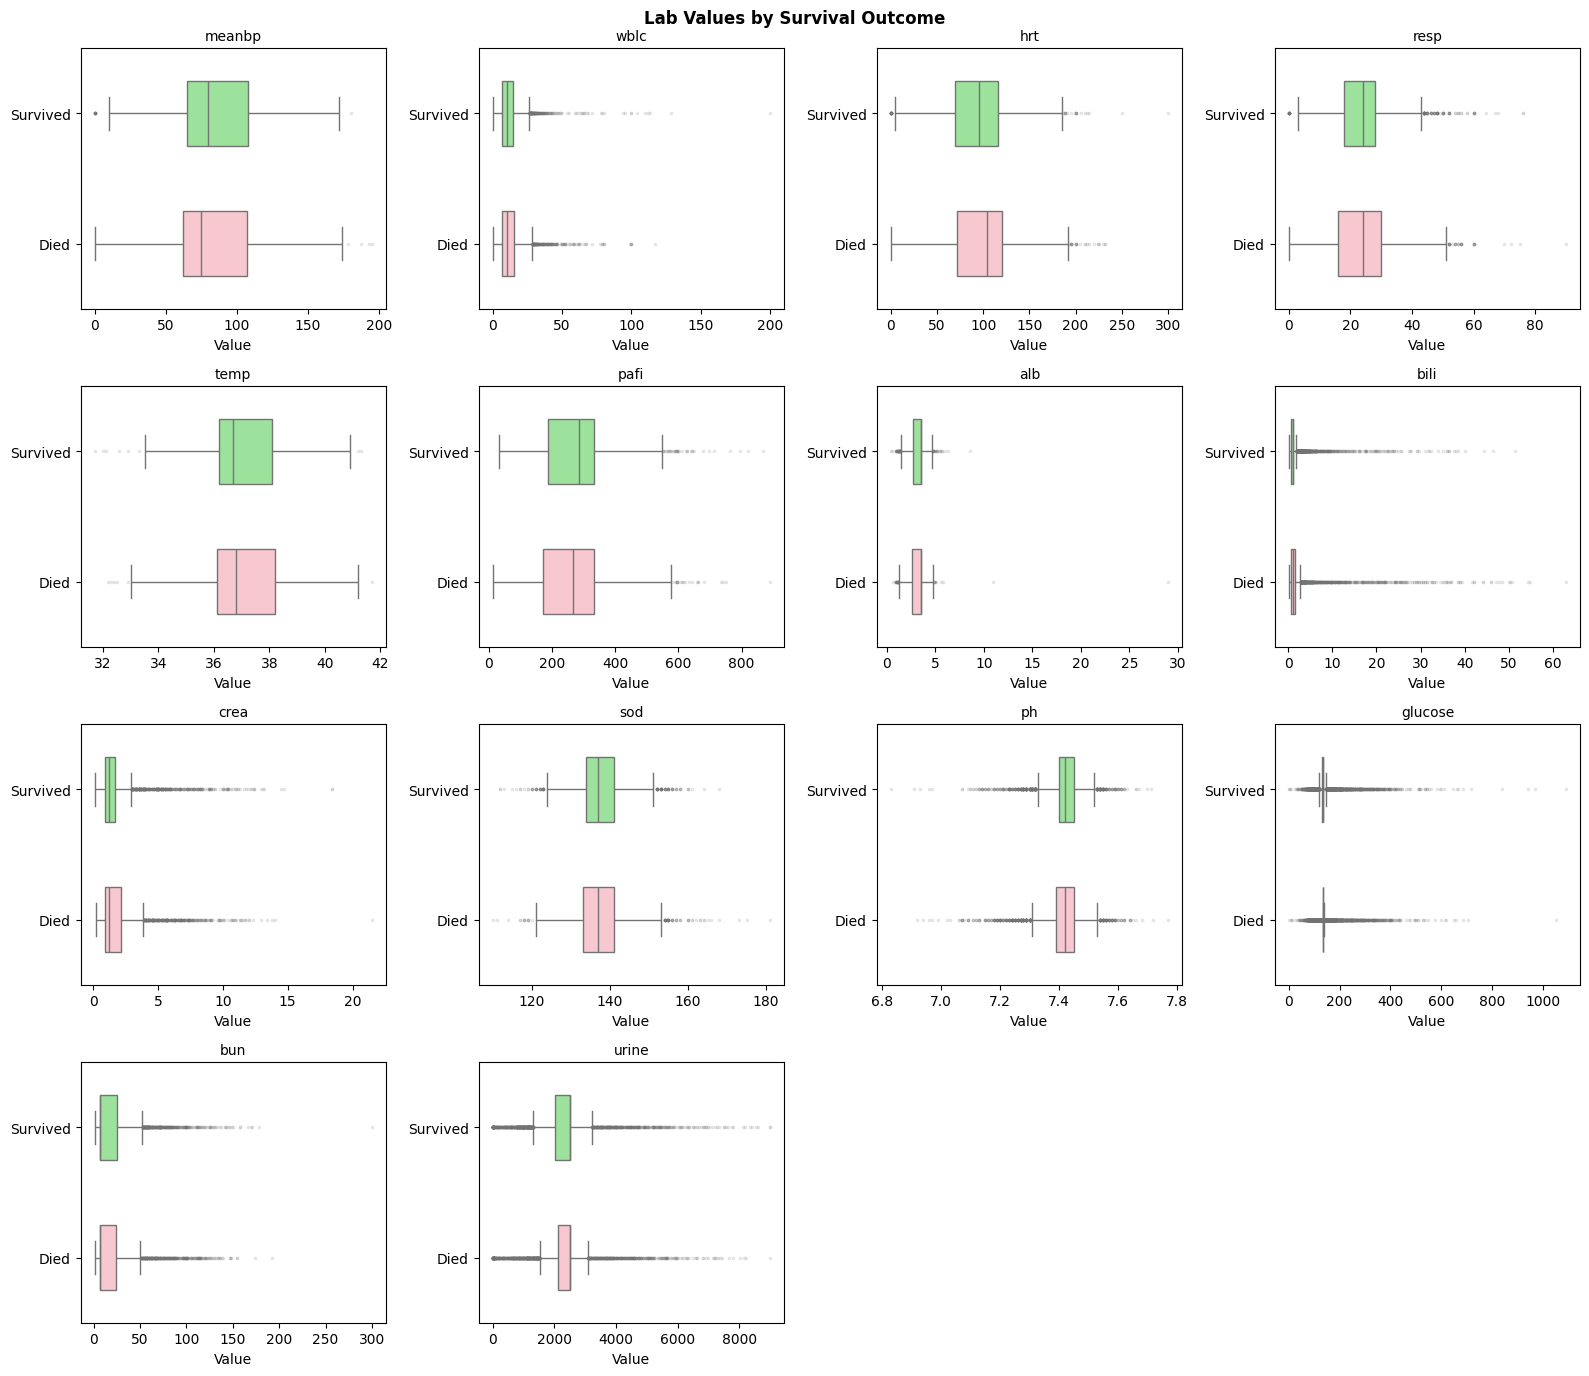

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for i, col in enumerate(LAB_COLS):
    ax = axes.flat[i]
    sns.boxplot(
        data=df,
        y=TARGET_COL,
        x=col,
        ax=ax,
        orient="h",
        palette=["lightgreen", "pink"],
        width=0.5,
        flierprops=dict(marker=".", alpha=0.2, markersize=3),
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Survived", "Died"])

for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)

fig.suptitle(
    "Lab Values by Survival Outcome",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## Section 5: Demographic Analysis

- Mortality gradual decline as wealth increases
- Asian group a bit more mortality 

In [13]:
def plot_mortality_rate(df, col, target_col, overall_rate, ax, title=None, sort=True):
    rate = df.groupby(col, observed=True)[target_col].mean()
    rate = rate.sort_values(ascending=False)
    bars = ax.bar(
        range(len(rate)),
        rate.values * 100,
        edgecolor="white",
        width=0.6,
    )
    ax.axhline(
        overall_rate * 100,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Overall ({overall_rate:.1%})",
    )
    ax.set_title(title or f"Mortality Rate by {col}")
    ax.set_ylabel("180-Day Mortality (%)")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{v:.1%}",
            ha="center",
            fontsize=8,
        )

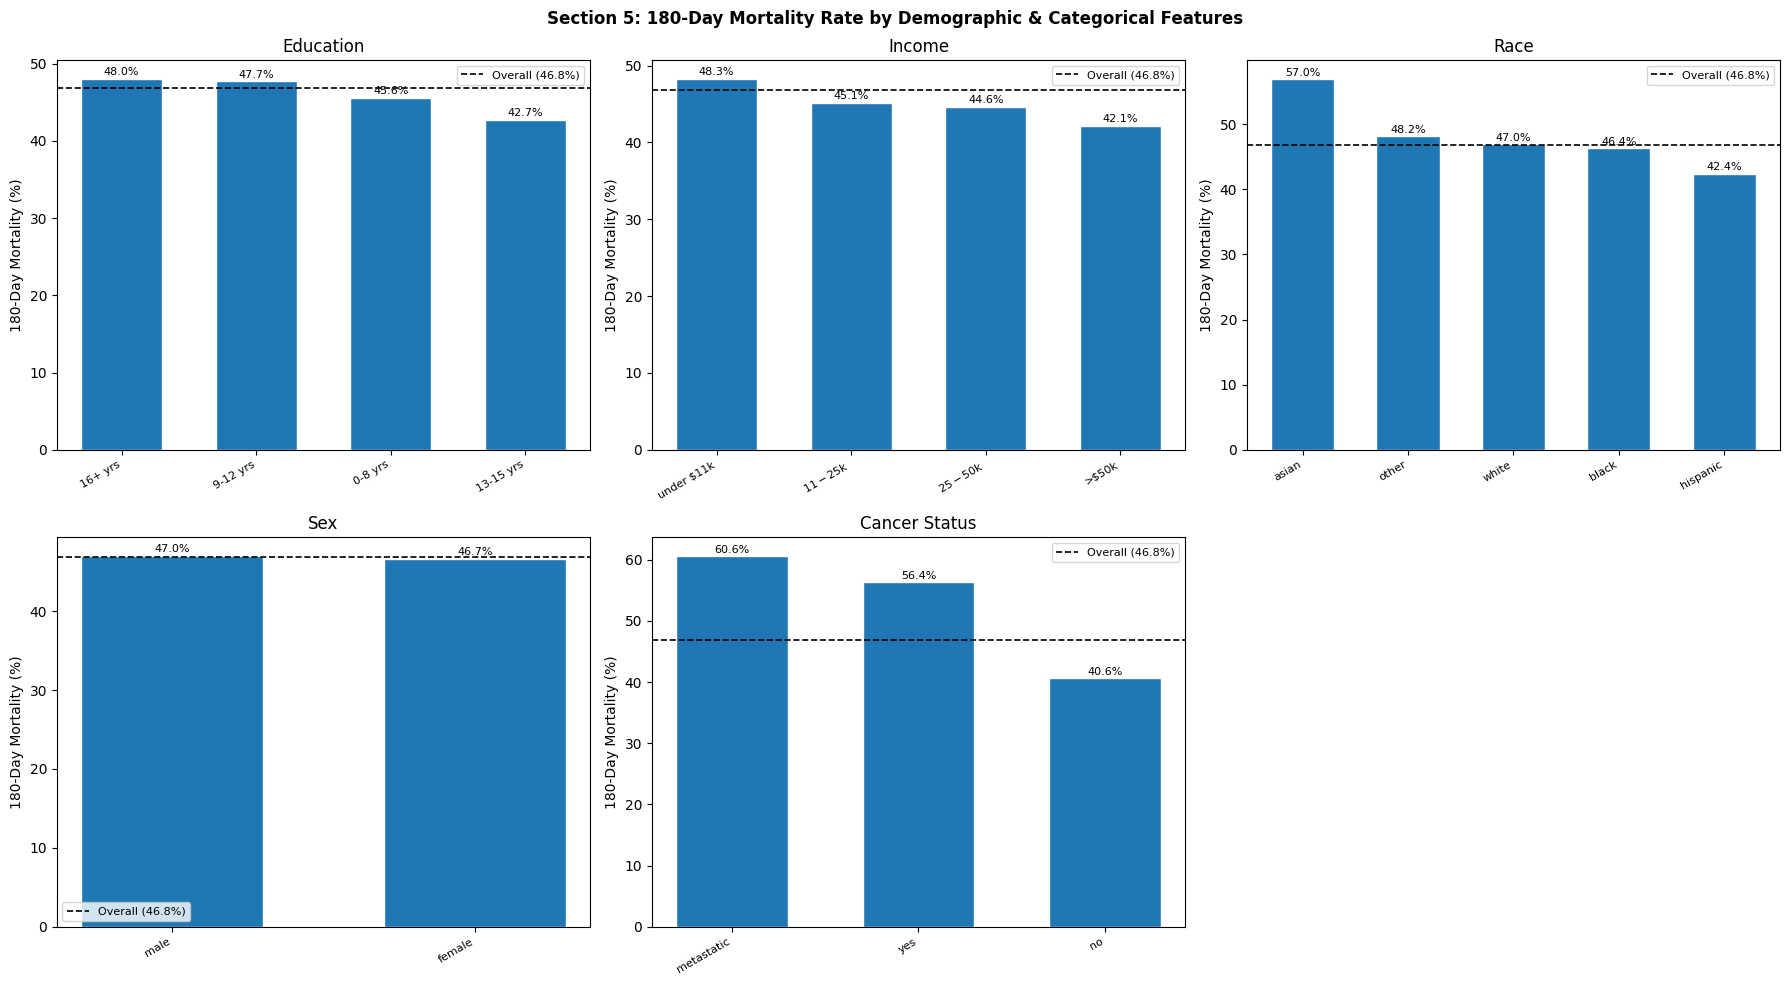

In [14]:
# education bins
edu_bins = [0, 8, 12, 15, 100]
edu_labels = ["0-8 yrs", "9-12 yrs", "13-15 yrs", "16+ yrs"]
df["edu_group"] = pd.cut(df["edu"], bins=edu_bins, labels=edu_labels, right=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_mortality_rate(
    df, "edu_group", TARGET_COL, overall_rate, axes[0, 0], title="Education", sort=False
)
plot_mortality_rate(df, "income", TARGET_COL, overall_rate, axes[0, 1], title="Income")
plot_mortality_rate(df, "race", TARGET_COL, overall_rate, axes[0, 2], title="Race")
plot_mortality_rate(df, "sex", TARGET_COL, overall_rate, axes[1, 0], title="Sex")
plot_mortality_rate(
    df, "ca", TARGET_COL, overall_rate, axes[1, 1], title="Cancer Status"
)
axes[1, 2].set_visible(False)

fig.suptitle(
    "Section 5: 180-Day Mortality Rate by Demographic & Categorical Features",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

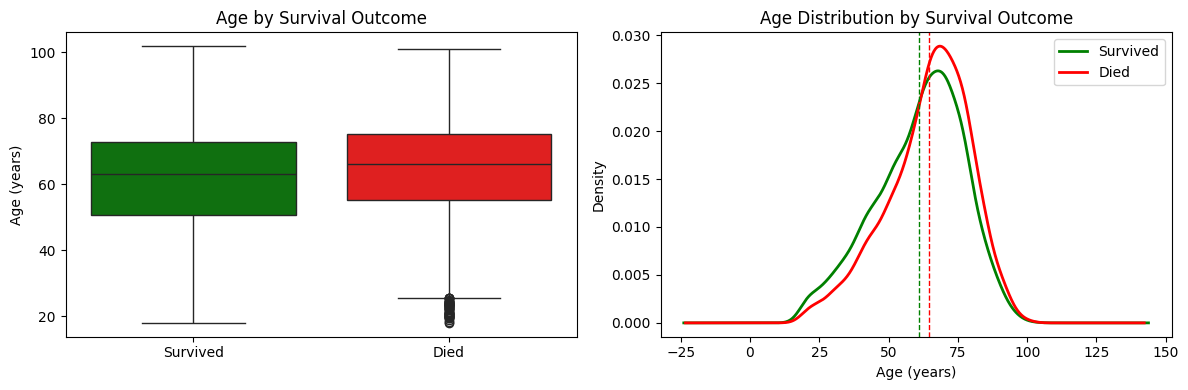

In [20]:
# Survivorship by age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x=TARGET_COL, y="age", ax=axes[0], palette=["green", "red"])
axes[0].set_title("Age by Survival Outcome")
axes[0].set_xticklabels(["Survived", "Died"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

# KDE overlay
for label, grp, color in [("Survived", survivors, "green"), ("Died", died, "red")]:
    grp["age"].plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].axvline(survivors["age"].mean(), color="green", linestyle="--", linewidth=1)
axes[1].axvline(died["age"].mean(), color="red", linestyle="--", linewidth=1)
axes[1].set_title("Age Distribution by Survival Outcome")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 6: Disease Group Analysis

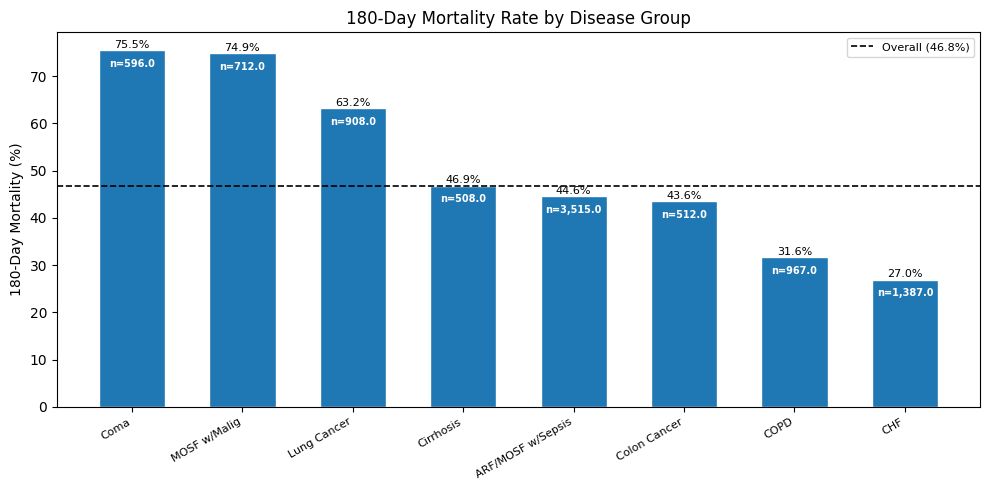

In [10]:
# mortality rate (uses utility) + patient count annotation
grp = df.groupby("dzgroup", observed=True)["death_180d"].agg(["mean", "count"])
grp.columns = ["Mortality", "N"]
grp = grp.sort_values("Mortality", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_mortality_rate(
    df,
    "dzgroup",
    TARGET_COL,
    overall_rate,
    ax,
    title="180-Day Mortality Rate by Disease Group",
)
# annotate patient counts below percentage labels
for i, (_, row) in enumerate(grp.iterrows()):
    ax.text(
        i,
        row["Mortality"] * 100 - 3.5,
        f"n={row['N']:,}",
        ha="center",
        fontsize=7,
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

---
## Section 7: DNR Status

- **no dnr**: no order placed
- **dnr before sadm**:  order existed before study admission
- **dnr after sadm**: order placed during the admission (possibly due to detereorating conditions)


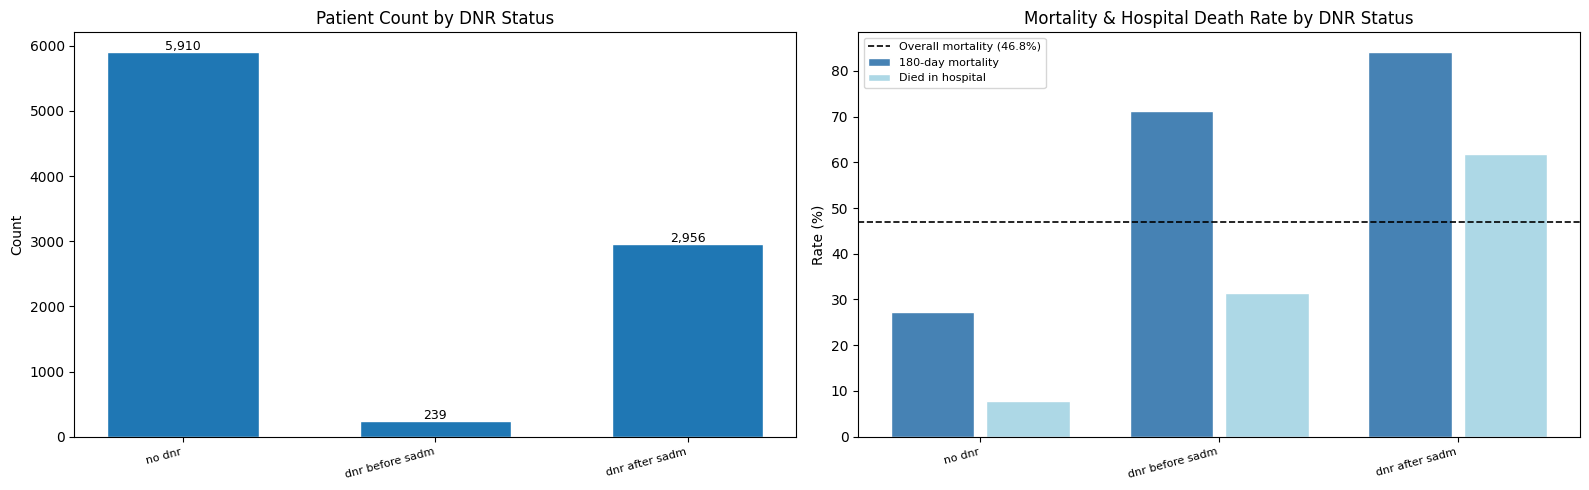

In [11]:
DNR_ORDER = ["no dnr", "dnr before sadm", "dnr after sadm"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df["dnr"].value_counts().reindex(DNR_ORDER)

# DNR count
axes[0].bar(range(3), counts.values, edgecolor="white", width=0.6)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[0].set_title("Patient Count by DNR Status")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

# DNR status compare
mort = df.groupby("dnr", observed=True)["death_180d"].mean().reindex(DNR_ORDER)
hosp = df.groupby("dnr", observed=True)["hospdead"].mean().reindex(DNR_ORDER)
x = range(3)

axes[1].bar(
    [i - 0.2 for i in x],
    mort.values * 100,
    width=0.35,
    color="steelblue",
    edgecolor="white",
    label="180-day mortality",
)
axes[1].bar(
    [i + 0.2 for i in x],
    hosp.values * 100,
    width=0.35,
    color="lightblue",
    edgecolor="white",
    label="Died in hospital",
)
axes[1].axhline(
    overall_rate * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall mortality ({overall_rate:.1%})",
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Mortality & Hospital Death Rate by DNR Status")
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

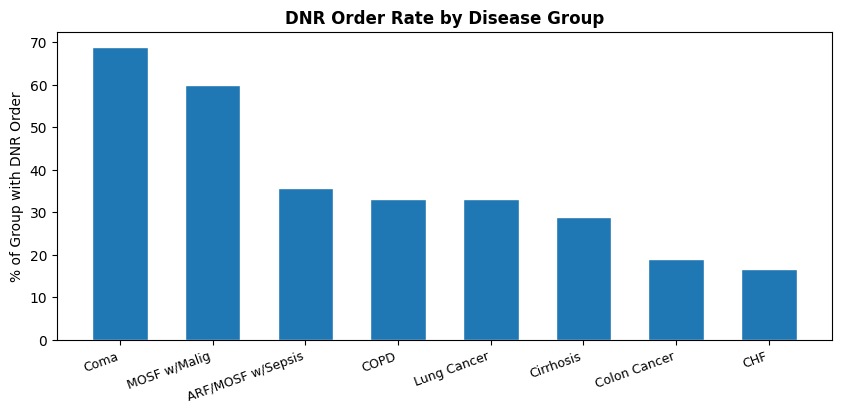

In [12]:
# DNR rate by Disease Group
dnr_rate = (
    df[df["dnr"] != "no dnr"].groupby("dzgroup", observed=True).size()
    / df.groupby("dzgroup", observed=True).size()
)
dnr_rate = dnr_rate.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(dnr_rate)),
    dnr_rate.values * 100,
    edgecolor="white",
    width=0.6,
)
ax.set_xticks(range(len(dnr_rate)))
ax.set_xticklabels(dnr_rate.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% of Group with DNR Order")
ax.set_title("DNR Order Rate by Disease Group", fontweight="bold")
plt.show()